In [2]:
#Cell 1 — imports and setup
# ============================================================
# MODULE 2: EXPLORATORY DATA ANALYSIS (EDA)
# Project: Startup Success Prediction
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings, os
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
COLORS = {'acquired': '#2ecc71', 'closed': '#e74c3c'}
STATUS_PALETTE = ['#e74c3c', '#2ecc71']

# Paths
BASE_DIR    = r"C:\Users\User\Documents\StartupSucessPrediction"
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
PLOTS_DIR   = os.path.join(BASE_DIR, "outputs", "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

# Helper: save every plot automatically to laptop
def save_plot(filename, dpi=150):
    path = os.path.join(PLOTS_DIR, filename)
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f" Saved → {path}")

print("EDA setup complete!")

EDA setup complete!


In [3]:
#Cell 2 — load the clean dataset from Module 1
# Load the clean dataset saved by Module 1
df = pd.read_csv(os.path.join(OUTPUTS_DIR, 'clean_dataset.csv'))

print("Clean dataset loaded!")
print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nTarget distribution:")
print(df['status'].value_counts())
print(f"\nSample rows:")
df.head()

Clean dataset loaded!
Shape  : (778, 43)
Columns: ['latitude', 'longitude', 'age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year', 'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones', 'is_CA', 'is_NY', 'is_MA', 'is_TX', 'is_otherstate', 'is_software', 'is_web', 'is_mobile', 'is_enterprise', 'is_advertising', 'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting', 'is_othercategory', 'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'has_roundD', 'avg_participants', 'is_top500', 'status', 'city_encoded', 'state_encoded', 'category_encoded', 'funding_efficiency', 'investor_strength', 'milestone_speed', 'network_funding_ratio', 'is_top_state', 'log_funding']

Target distribution:
status
1    477
0    301
Name: count, dtype: int64

Sample rows:


,latitude,longitude,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,...,status,city_encoded,state_encoded,category_encoded,funding_efficiency,investor_strength,milestone_speed,network_funding_ratio,is_top_state,log_funding
0,42.358880,-71.056820,2.2493,3.0027,4.6685,6.7041,3,3,375000,3,...,1,173,2,19,9.375000e+04,2,0.529241,0.216846,1,12.834684
1,37.238916,-121.973718,5.1260,9.9973,7.0055,7.0055,9,4,40100000,1,...,1,108,2,8,8.020000e+06,6,0.124914,0.486305,1,17.506887
2,32.901049,-117.192656,1.0329,1.0329,1.4575,2.2055,5,1,2600000,2,...,1,173,2,34,1.300000e+06,1,0.813835,0.317037,1,14.771022
3,37.320309,-122.050040,3.1315,5.3151,6.0027,6.0027,5,3,40000000,1,...,1,55,2,30,1.000000e+07,3,0.142802,0.270206,1,17.504390
4,37.779281,-122.419236,0.0000,1.6685,0.0384,0.0384,2,2,1300000,1,...,0,174,2,11,4.333333e+05,5,0.909091,0.132645,1,14.077876


 Saved → C:\Users\User\Documents\StartupSucessPrediction\outputs\plots\01_target_distribution.png


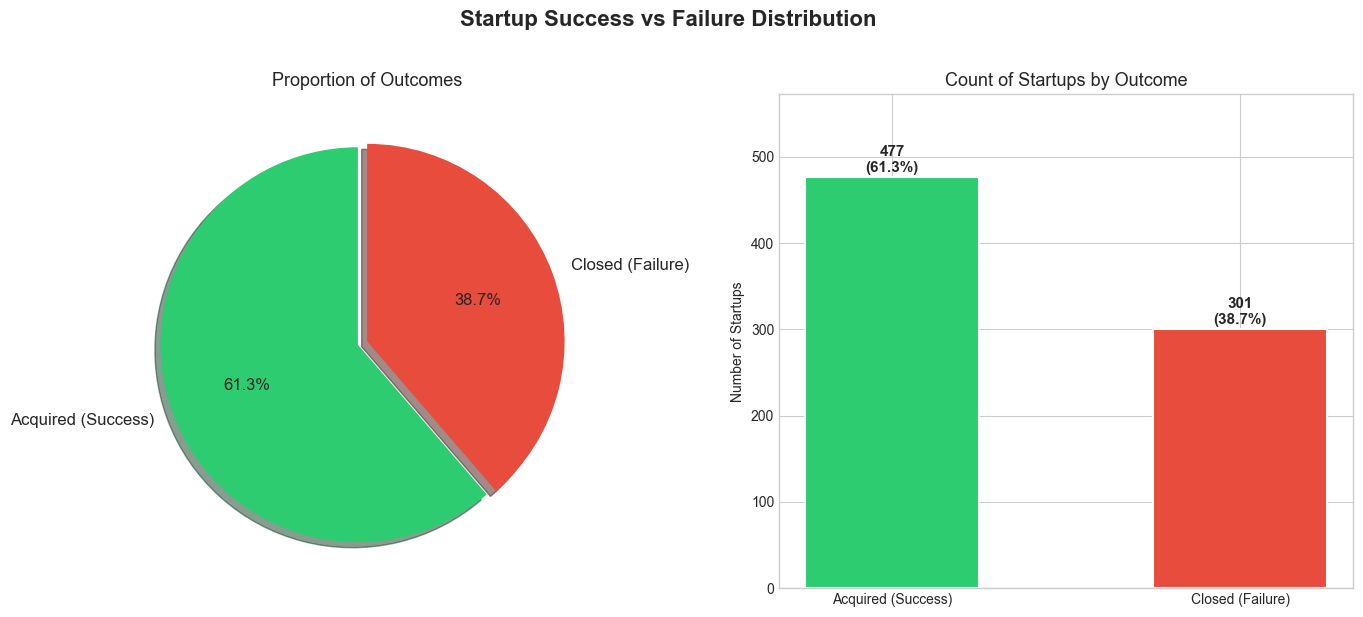

In [4]:
#Cell 3 — plot 1: target class distribution (pie + bar)
# ============================================================
# PLOT 1: TARGET CLASS DISTRIBUTION
# Shows how many startups succeeded vs failed
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Startup Success vs Failure Distribution',
             fontsize=16, fontweight='bold', y=1.02)

counts = df['status'].value_counts()
labels = ['Acquired (Success)', 'Closed (Failure)']
colors = ['#2ecc71', '#e74c3c']

# Pie chart
axes[0].pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0),
    shadow=True,
    textprops={'fontsize': 12}
)
axes[0].set_title('Proportion of Outcomes', fontsize=13)

# Bar chart
bars = axes[1].bar(labels, counts.values, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title('Count of Startups by Outcome', fontsize=13)
axes[1].set_ylabel('Number of Startups')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'{val}\n({val/len(df)*100:.1f}%)',
                ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, counts.max() * 1.2)

plt.tight_layout()
save_plot('01_target_distribution.png')
plt.show()

 Saved → C:\Users\User\Documents\StartupSucessPrediction\outputs\plots\02_funding_distribution.png


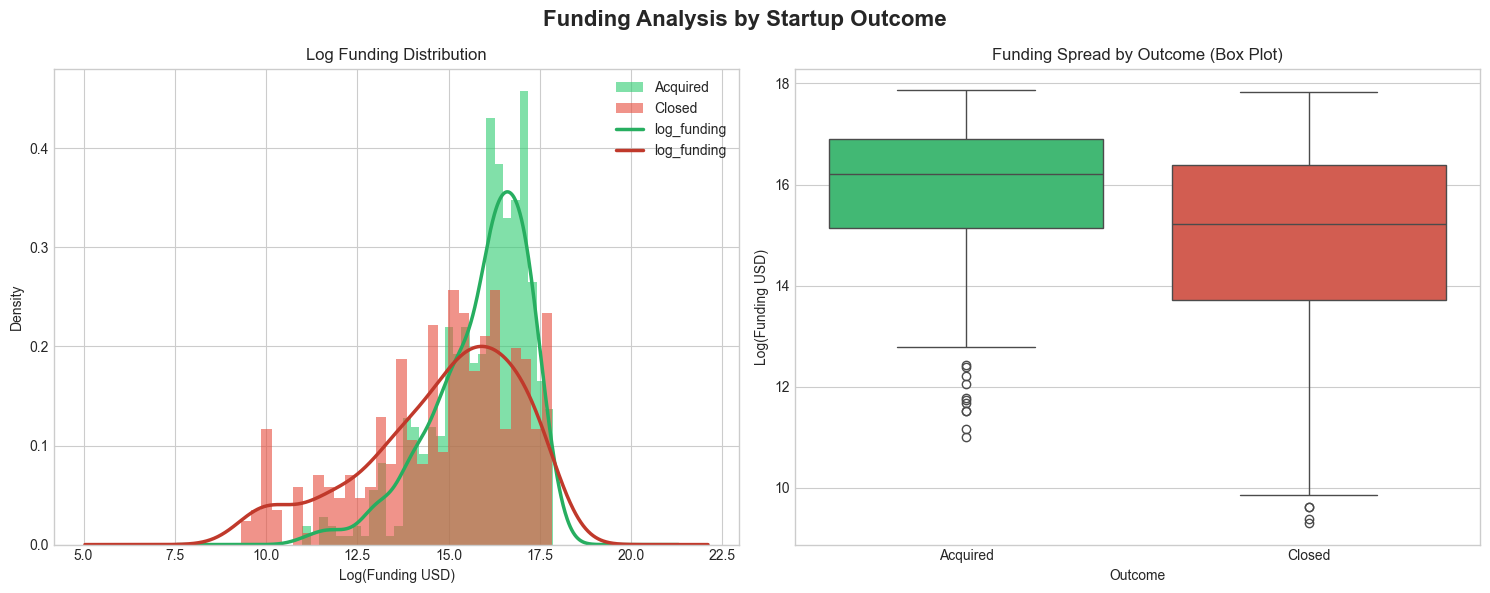

In [5]:
#Cell 4 — plot 2: funding distribution by outcome
# ============================================================
# PLOT 2: FUNDING DISTRIBUTION BY OUTCOME
# Do acquired startups raise more money?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Funding Analysis by Startup Outcome',
             fontsize=16, fontweight='bold')

acquired = df[df['status'] == 1]['log_funding']
closed   = df[df['status'] == 0]['log_funding']

# Histogram with KDE overlay
axes[0].hist(acquired, bins=30, alpha=0.6, color='#2ecc71',
            label='Acquired', density=True)
axes[0].hist(closed, bins=30, alpha=0.6, color='#e74c3c',
            label='Closed', density=True)
acquired.plot.kde(ax=axes[0], color='#27ae60', linewidth=2.5)
closed.plot.kde(ax=axes[0], color='#c0392b', linewidth=2.5)
axes[0].set_title('Log Funding Distribution')
axes[0].set_xlabel('Log(Funding USD)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Box plot
funding_plot_df = pd.DataFrame({
    'Log Funding'  : pd.concat([acquired, closed]),
    'Outcome'      : ['Acquired'] * len(acquired) + ['Closed'] * len(closed)
})
sns.boxplot(data=funding_plot_df, x='Outcome', y='Log Funding',
            palette={'Acquired':'#2ecc71', 'Closed':'#e74c3c'}, ax=axes[1])
axes[1].set_title('Funding Spread by Outcome (Box Plot)')
axes[1].set_ylabel('Log(Funding USD)')

plt.tight_layout()
save_plot('02_funding_distribution.png')
plt.show()

 Saved → C:\Users\User\Documents\StartupSucessPrediction\outputs\plots\03_state_success_rate.png


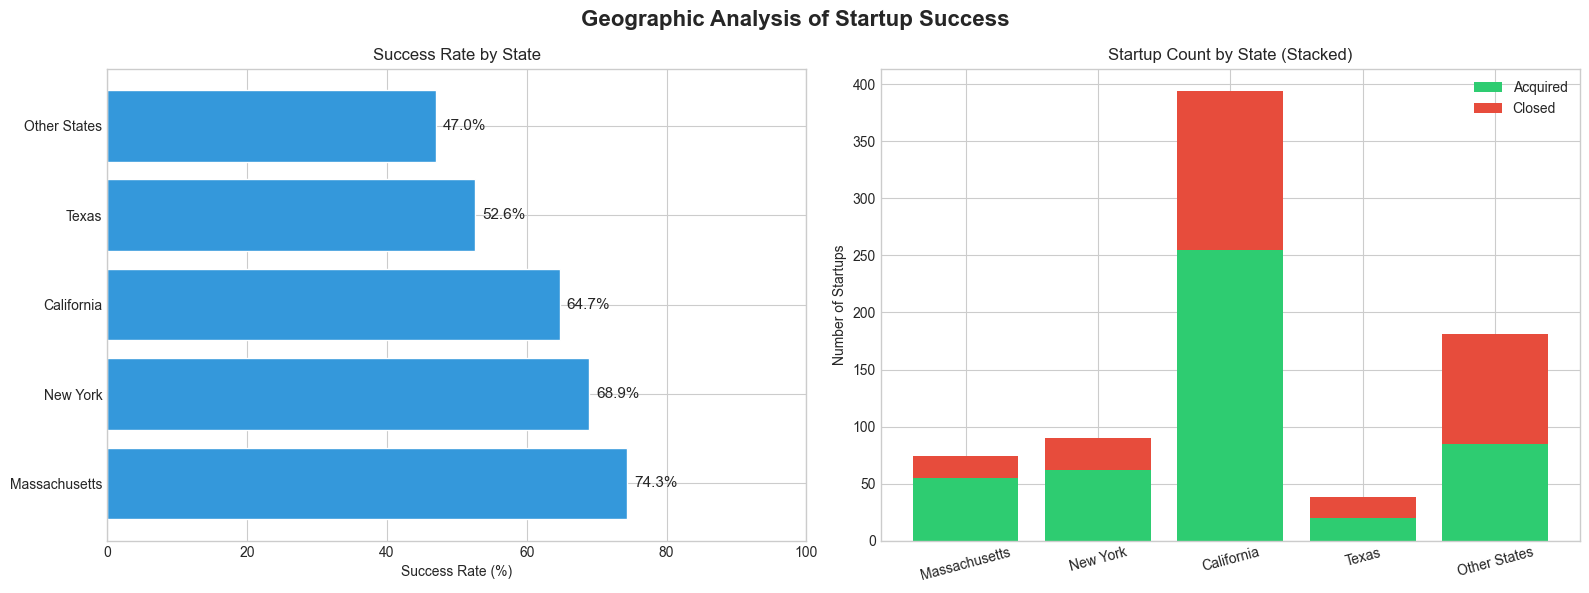

In [6]:
#Cell 5 — plot 3: state-wise success rate
# ============================================================
# PLOT 3: STATE-WISE SUCCESS RATE
# Which US states produce the most successful startups?
# ============================================================

state_cols = {'is_CA':'California', 'is_NY':'New York',
              'is_MA':'Massachusetts', 'is_TX':'Texas',
              'is_otherstate':'Other States'}

state_data = []
for col, name in state_cols.items():
    if col in df.columns:
        subset = df[df[col] == 1]
        total    = len(subset)
        acquired = (subset['status'] == 1).sum()
        rate     = acquired / total * 100 if total > 0 else 0
        state_data.append({'State': name, 'Total': total,
                           'Acquired': acquired, 'Success Rate %': rate})

state_df = pd.DataFrame(state_data).sort_values('Success Rate %', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Geographic Analysis of Startup Success',
             fontsize=16, fontweight='bold')

# Success rate bar chart
bars = axes[0].barh(state_df['State'], state_df['Success Rate %'],
                    color='#3498db', edgecolor='white')
axes[0].set_xlabel('Success Rate (%)')
axes[0].set_title('Success Rate by State')
axes[0].set_xlim(0, 100)
for bar, val in zip(bars, state_df['Success Rate %']):
    axes[0].text(val + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=11)

# Stacked bar: acquired vs closed per state
closed_counts = state_df['Total'] - state_df['Acquired']
axes[1].bar(state_df['State'], state_df['Acquired'],
            label='Acquired', color='#2ecc71')
axes[1].bar(state_df['State'], closed_counts,
            bottom=state_df['Acquired'], label='Closed', color='#e74c3c')
axes[1].set_title('Startup Count by State (Stacked)')
axes[1].set_ylabel('Number of Startups')
axes[1].legend()
plt.xticks(rotation=15)

plt.tight_layout()
save_plot('03_state_success_rate.png')
plt.show()

 Saved → C:\Users\User\Documents\StartupSucessPrediction\outputs\plots\04_sector_analysis.png


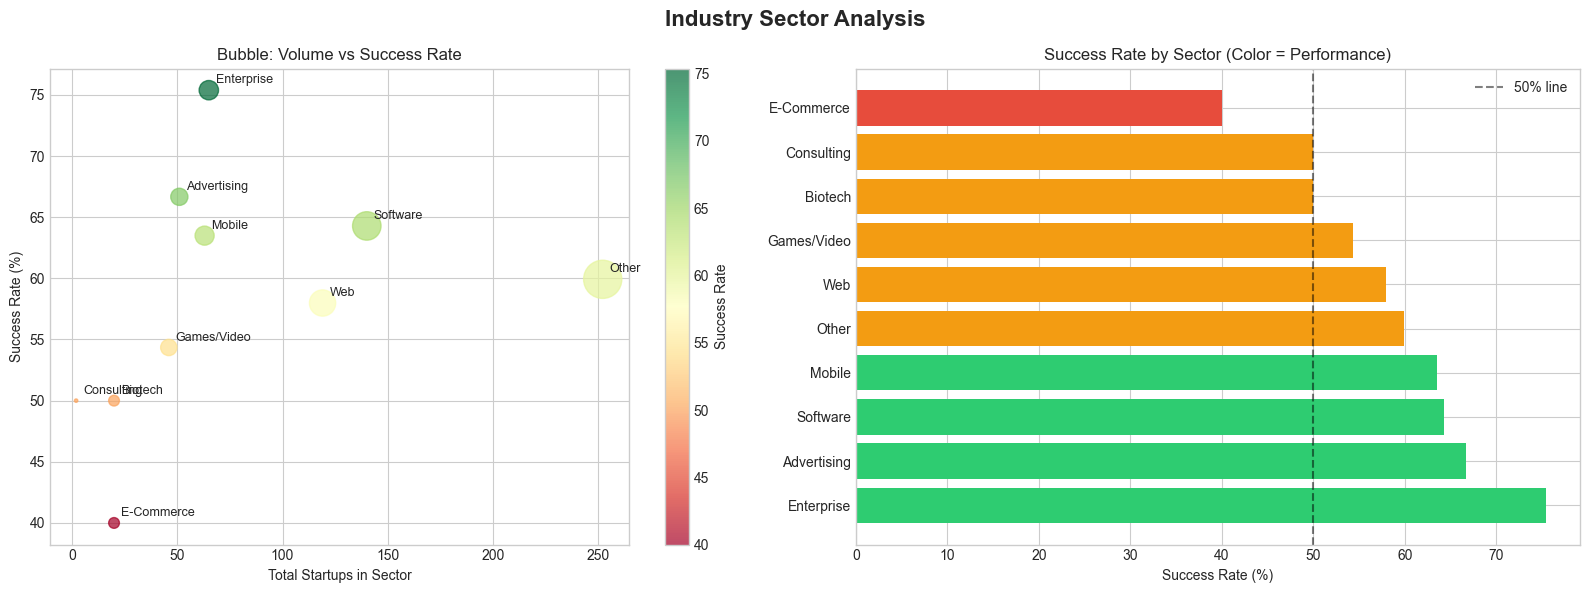

In [7]:
#Cell 6 — plot 4: sector / industry success rates
# ============================================================
# PLOT 4: INDUSTRY SECTOR SUCCESS RATES
# Which sectors produce winning startups?
# ============================================================

sector_cols = {
    'is_software'    : 'Software',
    'is_web'         : 'Web',
    'is_mobile'      : 'Mobile',
    'is_enterprise'  : 'Enterprise',
    'is_advertising' : 'Advertising',
    'is_gamesvideo'  : 'Games/Video',
    'is_ecommerce'   : 'E-Commerce',
    'is_biotech'     : 'Biotech',
    'is_consulting'  : 'Consulting',
    'is_othercategory': 'Other'
}

sector_stats = []
for col, name in sector_cols.items():
    if col in df.columns:
        subset   = df[df[col] == 1]
        total    = len(subset)
        acquired = (subset['status'] == 1).sum()
        rate     = acquired / total * 100 if total > 0 else 0
        sector_stats.append({'Sector': name, 'Total': total,
                             'Success Rate': rate})

sec_df = pd.DataFrame(sector_stats).sort_values('Success Rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Industry Sector Analysis', fontsize=16, fontweight='bold')

# Bubble chart: success rate vs total count
scatter = axes[0].scatter(
    sec_df['Total'], sec_df['Success Rate'],
    s=sec_df['Total'] * 3, alpha=0.7,
    c=sec_df['Success Rate'], cmap='RdYlGn'
)
for _, row in sec_df.iterrows():
    axes[0].annotate(row['Sector'],
        (row['Total'], row['Success Rate']),
        textcoords="offset points", xytext=(5,5), fontsize=9)
axes[0].set_xlabel('Total Startups in Sector')
axes[0].set_ylabel('Success Rate (%)')
axes[0].set_title('Bubble: Volume vs Success Rate')
plt.colorbar(scatter, ax=axes[0], label='Success Rate')

# Horizontal bar
bar_colors = ['#2ecc71' if r >= 60 else '#f39c12' if r >= 45 else '#e74c3c'
              for r in sec_df['Success Rate']]
axes[1].barh(sec_df['Sector'], sec_df['Success Rate'], color=bar_colors)
axes[1].axvline(50, color='black', linestyle='--', alpha=0.5, label='50% line')
axes[1].set_xlabel('Success Rate (%)')
axes[1].set_title('Success Rate by Sector (Color = Performance)')
axes[1].legend()

plt.tight_layout()
save_plot('04_sector_analysis.png')
plt.show()


 Saved → C:\Users\User\Documents\StartupSucessPrediction\outputs\plots\05_correlation_heatmap.png


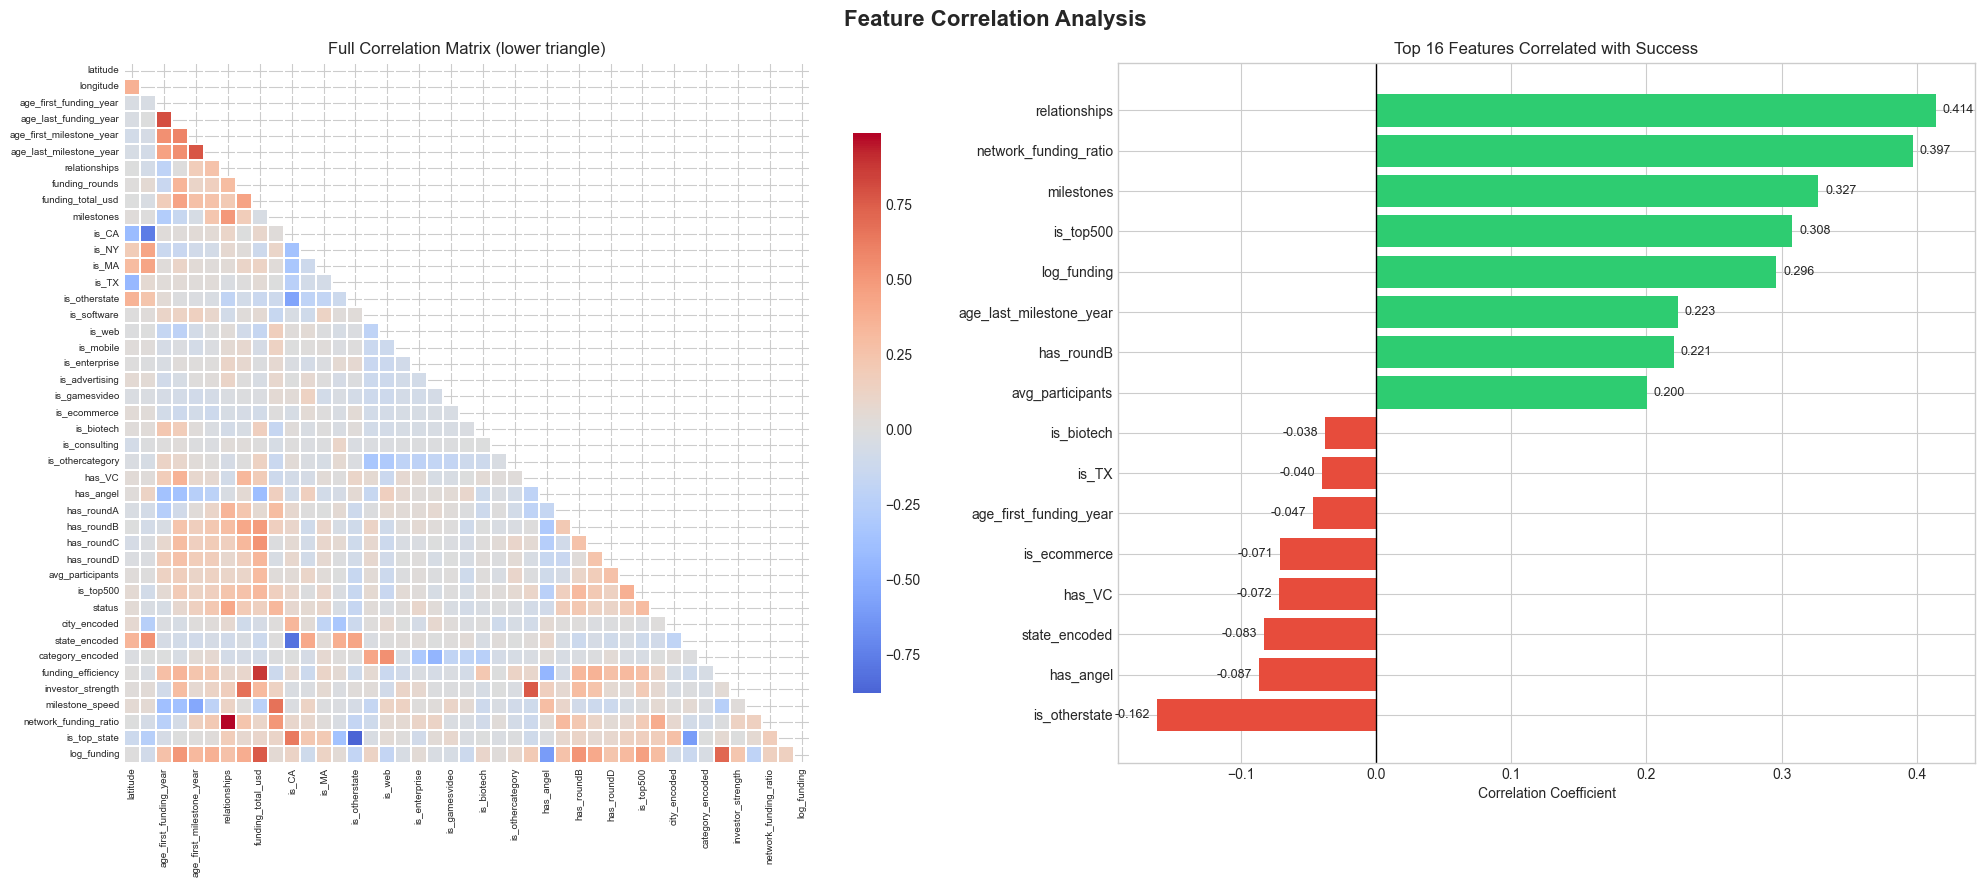

In [8]:
#Cell 7 — plot 5: full correlation heatmap
# ============================================================
# PLOT 5: CORRELATION HEATMAP
# Which features are most correlated with success?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('Feature Correlation Analysis', fontsize=16, fontweight='bold')

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Full heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False, cmap='coolwarm',
    center=0, linewidths=0.3, ax=axes[0],
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Full Correlation Matrix (lower triangle)')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

# Top correlations with target 'status'
target_corr = corr_matrix['status'].drop('status').sort_values()
top_corr = pd.concat([target_corr.head(8), target_corr.tail(8)])
bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in top_corr.values]
axes[1].barh(top_corr.index, top_corr.values, color=bar_colors)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Top 16 Features Correlated with Success')
axes[1].set_xlabel('Correlation Coefficient')
for i, (val, name) in enumerate(zip(top_corr.values, top_corr.index)):
    axes[1].text(val + (0.005 if val >= 0 else -0.005), i,
                f'{val:.3f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
save_plot('05_correlation_heatmap.png')
plt.show()


 Saved → C:\Users\User\Documents\StartupSucessPrediction\outputs\plots\06_funding_rounds_analysis.png


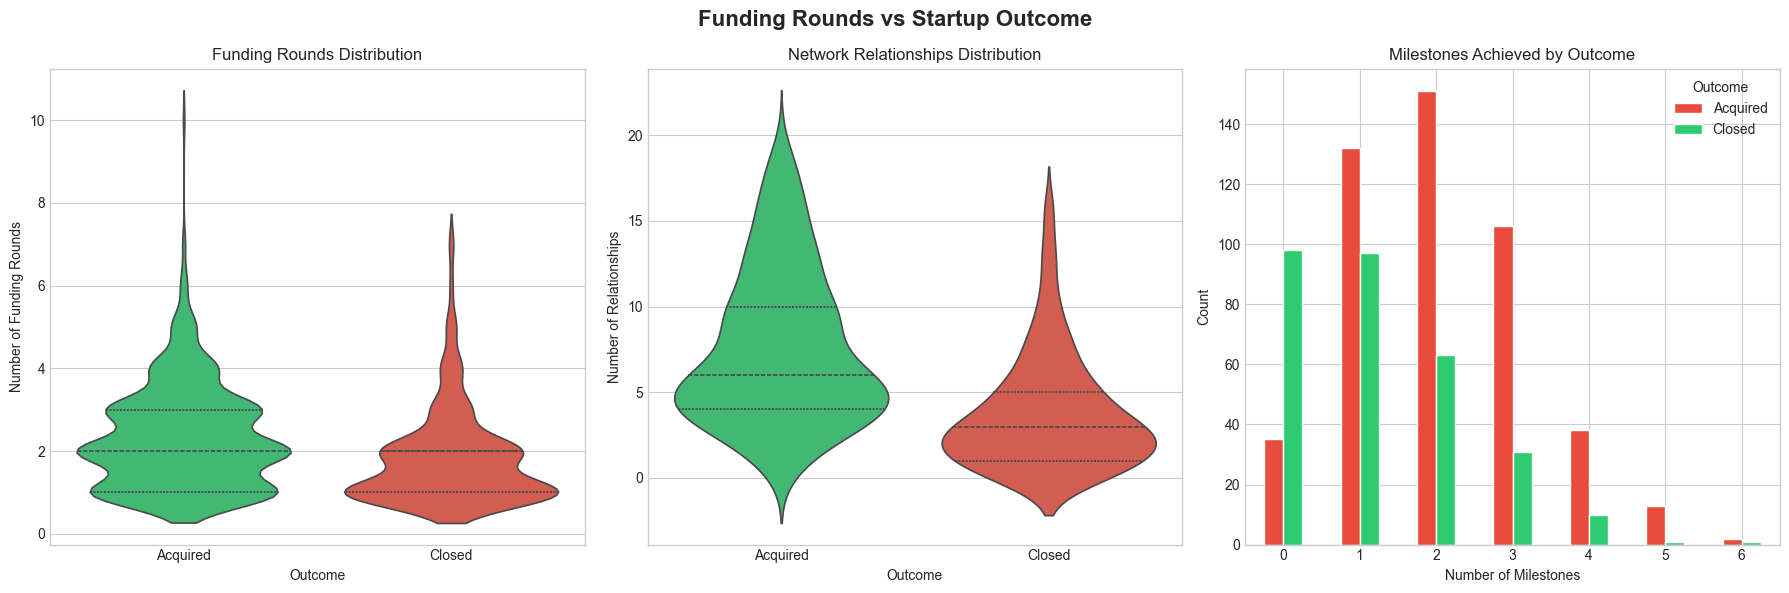

In [9]:
#Cell 8 — plot 6: funding rounds vs success (violin + swarm)
# ============================================================
# PLOT 6: FUNDING ROUNDS vs SUCCESS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Funding Rounds vs Startup Outcome',
             fontsize=16, fontweight='bold')

plot_df = df[['funding_rounds', 'relationships',
              'milestones', 'status']].copy()
plot_df['Outcome'] = plot_df['status'].map({1:'Acquired', 0:'Closed'})

# Violin: funding rounds
sns.violinplot(data=plot_df, x='Outcome', y='funding_rounds',
               palette={'Acquired':'#2ecc71', 'Closed':'#e74c3c'},
               ax=axes[0], inner='quartile')
axes[0].set_title('Funding Rounds Distribution')
axes[0].set_ylabel('Number of Funding Rounds')

# Violin: relationships (network size)
sns.violinplot(data=plot_df, x='Outcome', y='relationships',
               palette={'Acquired':'#2ecc71', 'Closed':'#e74c3c'},
               ax=axes[1], inner='quartile')
axes[1].set_title('Network Relationships Distribution')
axes[1].set_ylabel('Number of Relationships')

# Count plot: milestones achieved
milestone_counts = plot_df.groupby(['milestones', 'Outcome']).size().reset_index(name='count')
milestone_pivot  = milestone_counts.pivot(index='milestones', columns='Outcome', values='count').fillna(0)
milestone_pivot.plot(kind='bar', ax=axes[2],
                     color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[2].set_title('Milestones Achieved by Outcome')
axes[2].set_xlabel('Number of Milestones')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
save_plot('06_funding_rounds_analysis.png')
plt.show()

 Saved → C:\Users\User\Documents\StartupSucessPrediction\outputs\plots\07_investor_impact.png


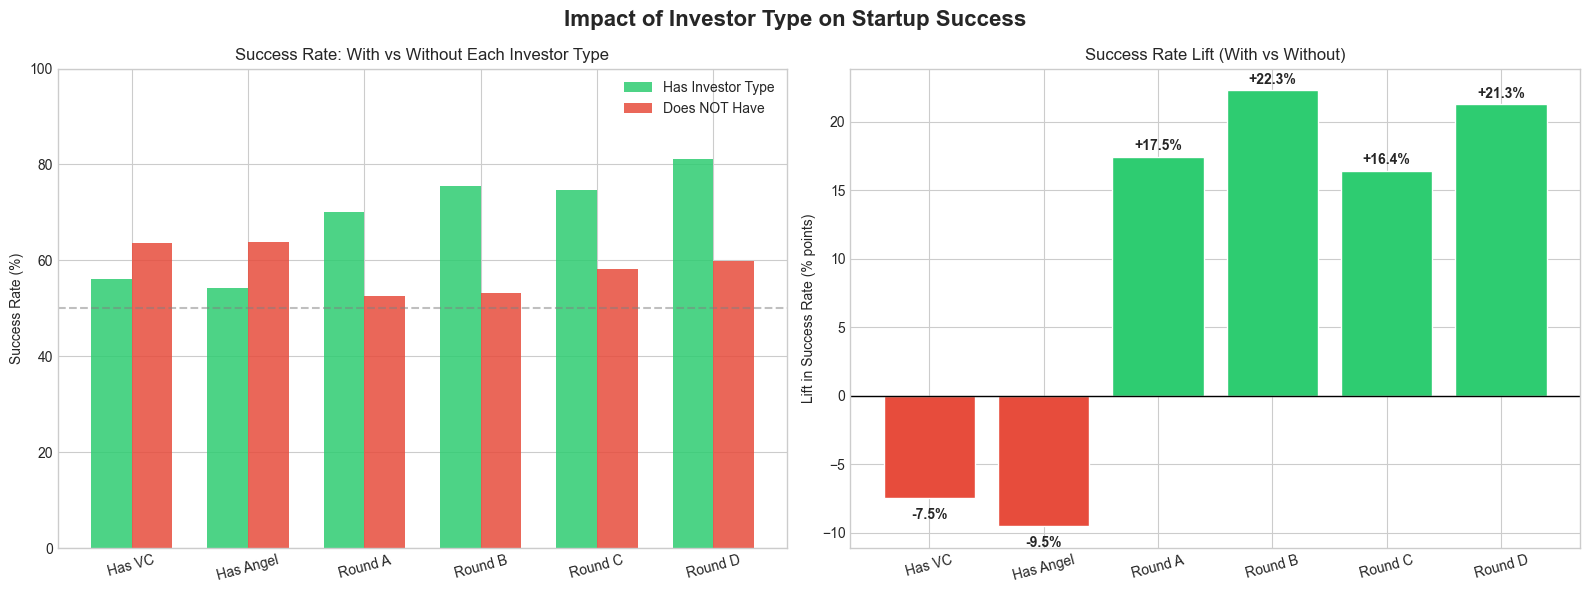

In [10]:
#Cell 9 — plot 7: investor type impact (VC vs Angel vs Rounds)
# ============================================================
# PLOT 7: INVESTOR TYPE IMPACT ON SUCCESS
# ============================================================

investor_features = ['has_VC', 'has_angel', 'has_roundA',
                     'has_roundB', 'has_roundC', 'has_roundD']
investor_labels   = ['Has VC', 'Has Angel', 'Round A',
                     'Round B', 'Round C', 'Round D']

success_rates_yes, success_rates_no = [], []
for feat in investor_features:
    if feat in df.columns:
        yes = df[df[feat] == 1]['status'].mean() * 100
        no  = df[df[feat] == 0]['status'].mean() * 100
        success_rates_yes.append(yes)
        success_rates_no.append(no)

x     = np.arange(len(investor_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Impact of Investor Type on Startup Success',
             fontsize=16, fontweight='bold')

# Grouped bar chart
bars1 = axes[0].bar(x - width/2, success_rates_yes, width,
                    label='Has Investor Type', color='#2ecc71', alpha=0.85)
bars2 = axes[0].bar(x + width/2, success_rates_no, width,
                    label='Does NOT Have', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(investor_labels, rotation=15)
axes[0].set_ylabel('Success Rate (%)')
axes[0].set_title('Success Rate: With vs Without Each Investor Type')
axes[0].legend()
axes[0].set_ylim(0, 100)
axes[0].axhline(50, linestyle='--', color='gray', alpha=0.5)

# Difference (lift) chart
lift = [y - n for y, n in zip(success_rates_yes, success_rates_no)]
lift_colors = ['#2ecc71' if l > 0 else '#e74c3c' for l in lift]
axes[1].bar(investor_labels, lift, color=lift_colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Success Rate Lift (With vs Without)')
axes[1].set_ylabel('Lift in Success Rate (% points)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(lift):
    axes[1].text(i, v + (0.5 if v >= 0 else -1.5),
                f'{v:+.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
save_plot('07_investor_impact.png')
plt.show()

 Saved → C:\Users\User\Documents\StartupSucessPrediction\outputs\plots\08_engineered_features.png


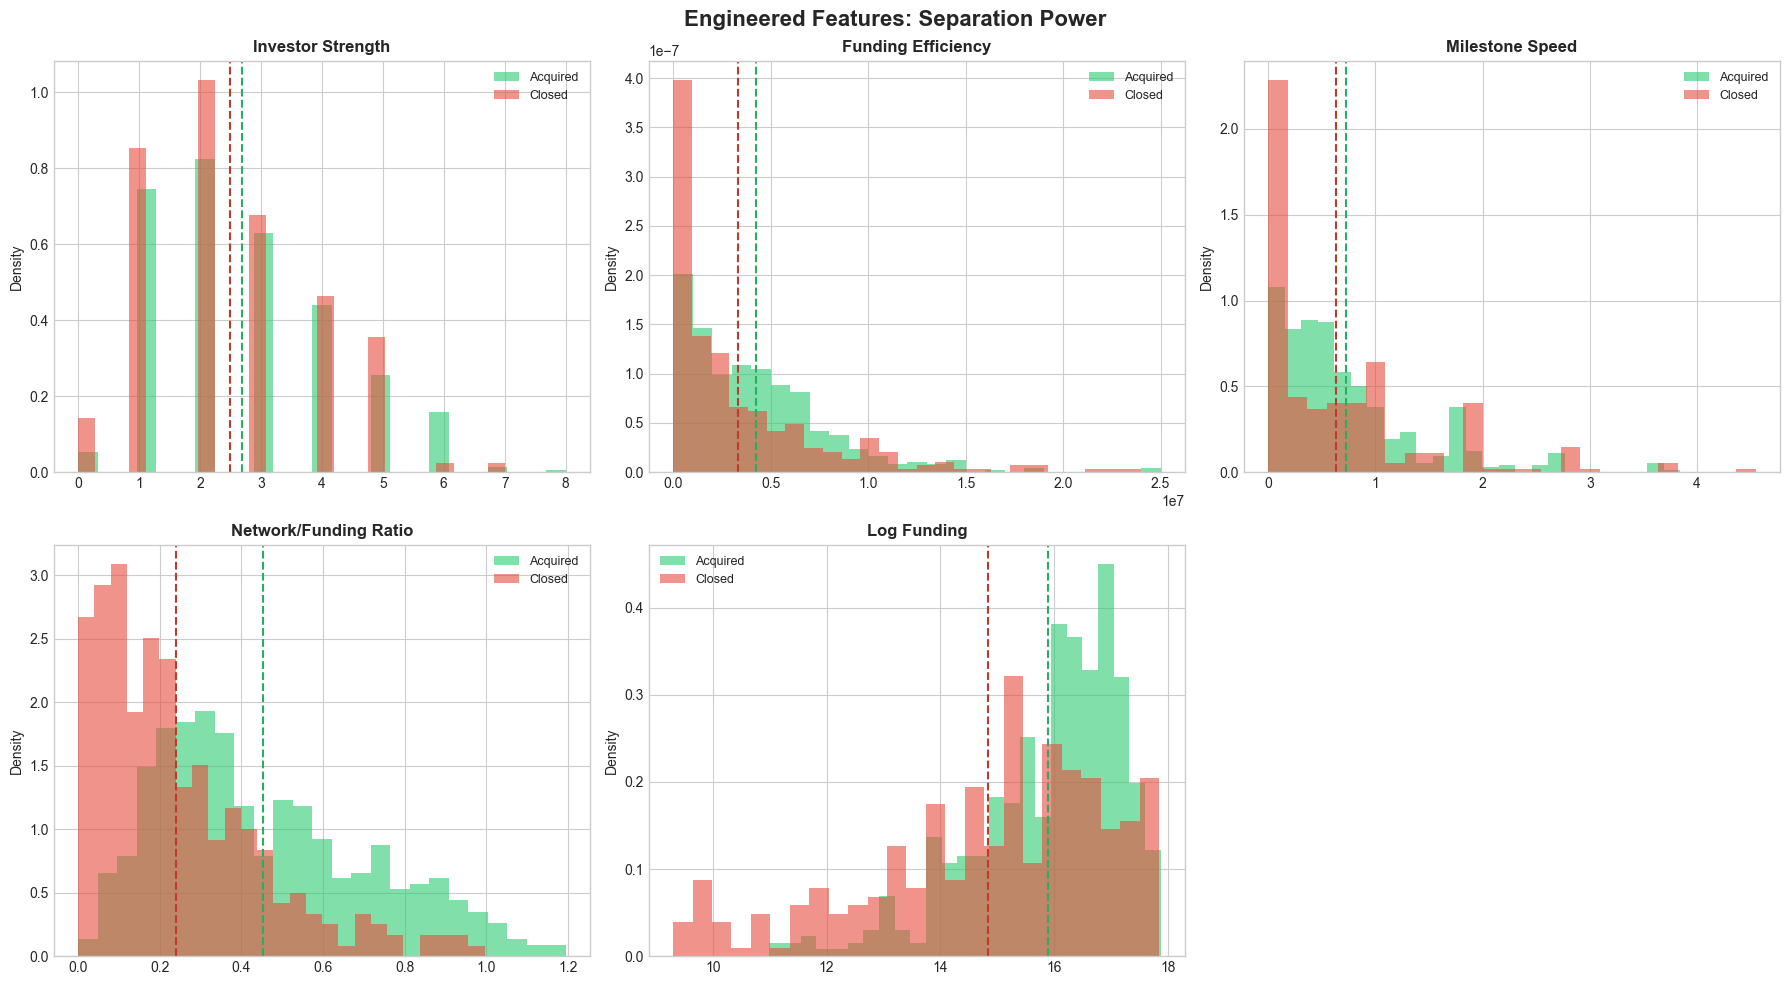

In [11]:
#Cell 10 — plot 8: engineered features distribution
# ============================================================
# PLOT 8: ENGINEERED FEATURES — Do they separate classes?
# ============================================================

eng_features = ['investor_strength', 'funding_efficiency',
                'milestone_speed', 'network_funding_ratio',
                'log_funding']
eng_labels   = ['Investor Strength', 'Funding Efficiency',
                'Milestone Speed', 'Network/Funding Ratio',
                'Log Funding']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Engineered Features: Separation Power',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(eng_features, eng_labels)):
    if feat not in df.columns:
        continue
    acq = df[df['status'] == 1][feat].dropna()
    cls = df[df['status'] == 0][feat].dropna()
    axes[i].hist(acq, bins=25, alpha=0.6, color='#2ecc71',
                label='Acquired', density=True)
    axes[i].hist(cls, bins=25, alpha=0.6, color='#e74c3c',
                label='Closed', density=True)
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)
    mean_acq = acq.mean()
    mean_cls = cls.mean()
    axes[i].axvline(mean_acq, color='#27ae60', linestyle='--',
                   label=f'Acq mean={mean_acq:.2f}')
    axes[i].axvline(mean_cls, color='#c0392b', linestyle='--',
                   label=f'Cls mean={mean_cls:.2f}')

axes[5].axis('off')
plt.tight_layout()
save_plot('08_engineered_features.png')
plt.show()

Saved → 09_pair_plot.png


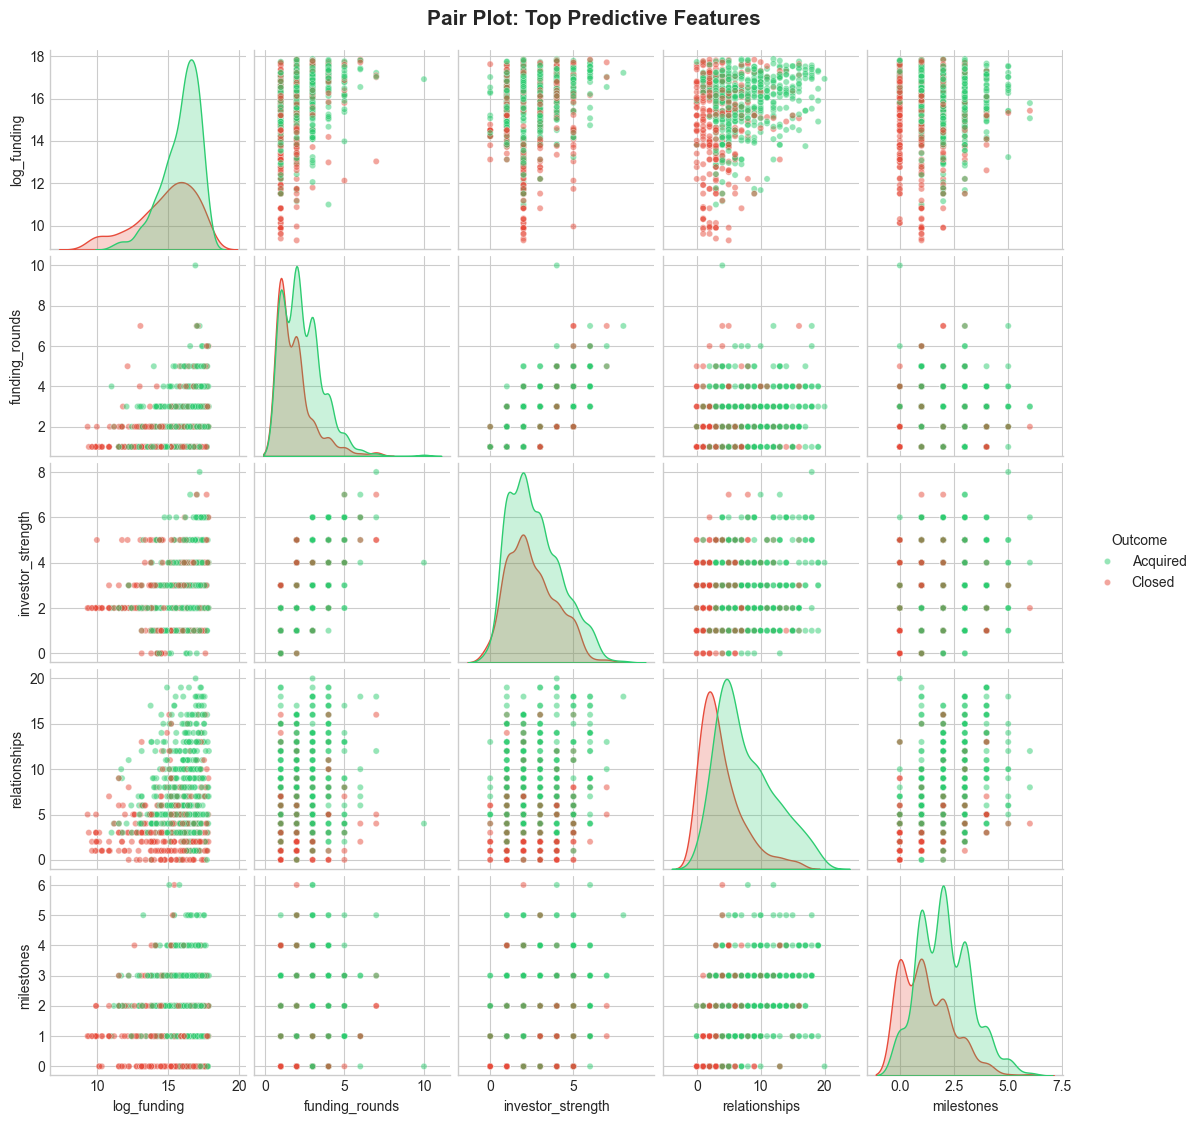

In [12]:
#Cell 11 — plot 9: pair plot of top features
# ============================================================
# PLOT 9: PAIR PLOT — Top 5 features against each other
# ============================================================

top_features = ['log_funding', 'funding_rounds',
                'investor_strength', 'relationships',
                'milestones', 'status']

pair_df = df[[f for f in top_features if f in df.columns]].copy()
pair_df['Outcome'] = pair_df['status'].map({1:'Acquired', 0:'Closed'})
pair_df.drop('status', axis=1, inplace=True)

pair_plot = sns.pairplot(
    pair_df, hue='Outcome',
    palette={'Acquired':'#2ecc71', 'Closed':'#e74c3c'},
    diag_kind='kde', plot_kws={'alpha':0.5, 's':20},
    height=2.2
)
pair_plot.fig.suptitle('Pair Plot: Top Predictive Features',
                       y=1.02, fontsize=15, fontweight='bold')
pair_plot.savefig(os.path.join(PLOTS_DIR, '09_pair_plot.png'),
                  dpi=130, bbox_inches='tight')
print("Saved → 09_pair_plot.png")
plt.show()


 Saved → 10_interactive_scatter.html (open in browser)


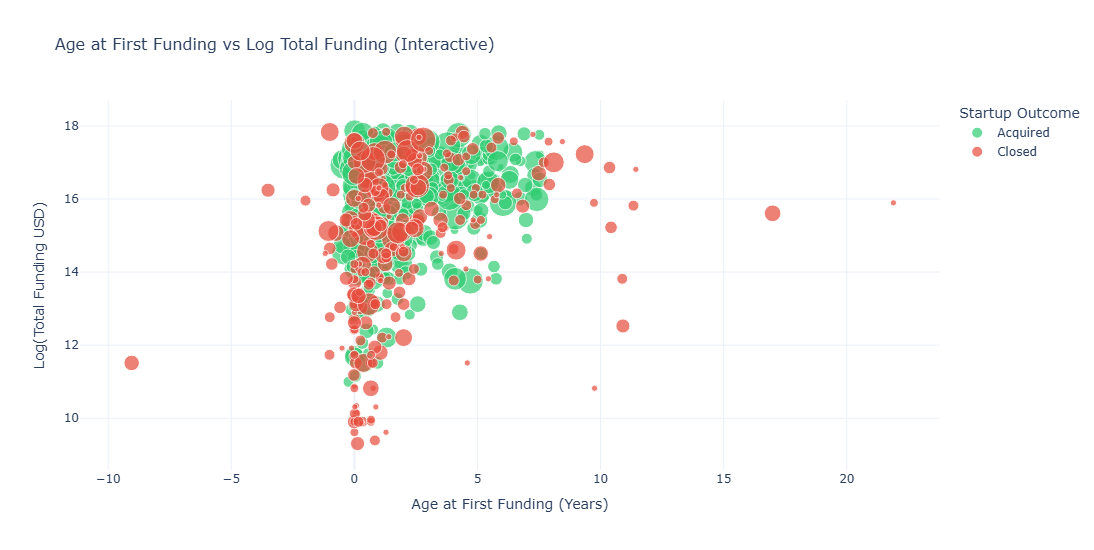

In [13]:
#Cell 12 — plot 10: interactive plotly chart (age vs funding)
# ============================================================
# PLOT 10: INTERACTIVE PLOTLY — Age at First Funding vs Total Funding
# This is your "wow" interactive chart for the project demo
# ============================================================

plot_df = df.copy()
plot_df['Outcome'] = plot_df['status'].map({1:'Acquired', 0:'Closed'})

fig = px.scatter(
    plot_df,
    x='age_first_funding_year',
    y='log_funding',
    color='Outcome',
    size='relationships',
    hover_data=['funding_rounds', 'milestones', 'investor_strength'],
    color_discrete_map={'Acquired':'#2ecc71', 'Closed':'#e74c3c'},
    title='Age at First Funding vs Log Total Funding (Interactive)',
    labels={
        'age_first_funding_year': 'Age at First Funding (Years)',
        'log_funding': 'Log(Total Funding USD)'
    },
    opacity=0.7,
    template='plotly_white'
)
fig.update_layout(
    title_font_size=16,
    legend_title_text='Startup Outcome',
    width=950, height=550
)

# Save as interactive HTML (open in browser!)
fig.write_html(os.path.join(PLOTS_DIR, '10_interactive_scatter.html'))
print(" Saved → 10_interactive_scatter.html (open in browser)")
fig.show()

 Saved → C:\Users\User\Documents\StartupSucessPrediction\outputs\plots\11_data_quality.png


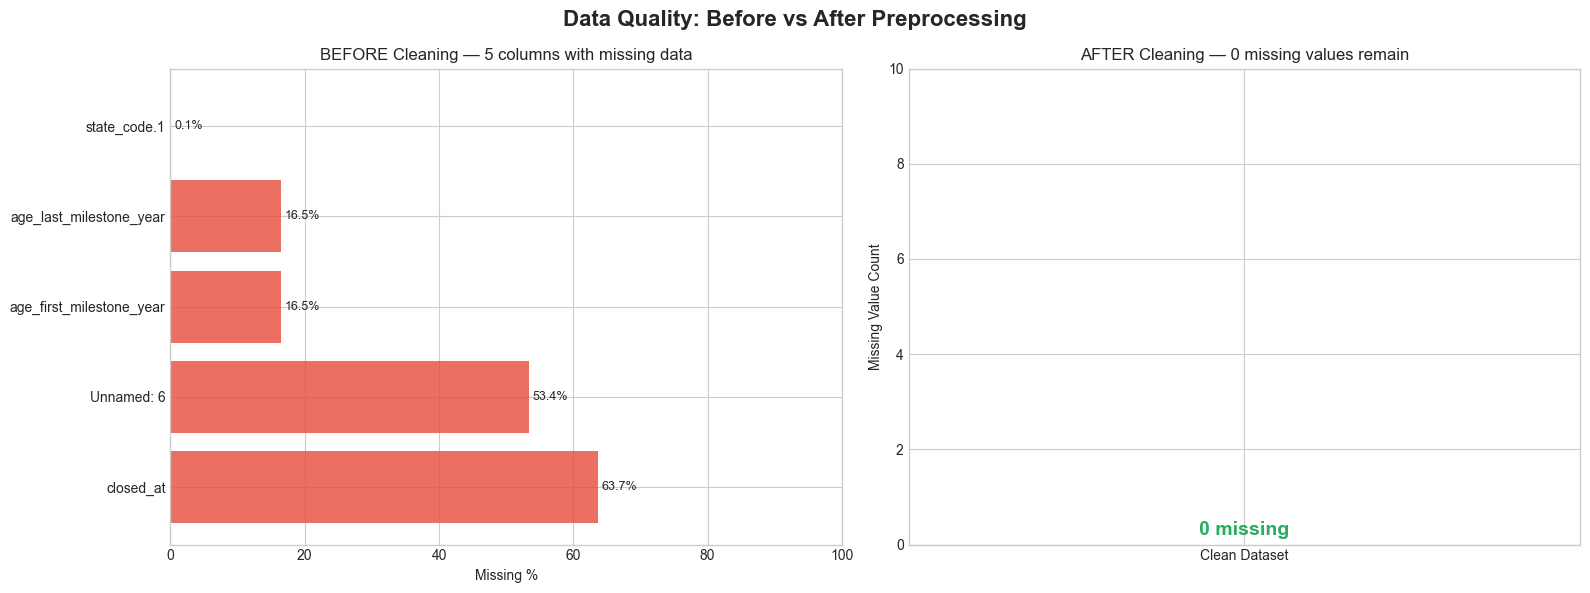

In [15]:
#Cell 13 — plot 11: missing values and data quality report
# ============================================================
# PLOT 11: MISSING VALUE ANALYSIS (Before vs After cleaning)
# ============================================================

raw_df = pd.read_csv(os.path.join(BASE_DIR, 'dataset', 'startup data.csv'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Data Quality: Before vs After Preprocessing',
             fontsize=16, fontweight='bold')

# Before cleaning
raw_missing = (raw_df.isnull().sum() / len(raw_df) * 100)
raw_missing = raw_missing[raw_missing > 0].sort_values(ascending=False)
axes[0].barh(raw_missing.index, raw_missing.values, color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Missing %')
axes[0].set_title(f'BEFORE Cleaning — {len(raw_missing)} columns with missing data')
axes[0].set_xlim(0, 100)
for i, v in enumerate(raw_missing.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# After cleaning
clean_missing = df.isnull().sum().sum()
axes[1].bar(['Clean Dataset'], [clean_missing], color='#2ecc71', width=0.3)
axes[1].set_title(f'AFTER Cleaning — {clean_missing} missing values remain')
axes[1].set_ylabel('Missing Value Count')
axes[1].set_ylim(0, 10)
axes[1].text(0, clean_missing + 0.2, f'{clean_missing} missing',
            ha='center', fontsize=14, fontweight='bold', color='#27ae60')

plt.tight_layout()
save_plot('11_data_quality.png')
plt.show()

In [17]:
#Cell 14 — EDA summary report saved to laptop
# ============================================================
# FINAL: PRINT AND SAVE EDA SUMMARY REPORT
# ============================================================

report = f"""
╔══════════════════════════════════════════════════════╗
║         EDA SUMMARY REPORT — STARTUP SUCCESS         ║
╠══════════════════════════════════════════════════════╣
║ Total Startups Analyzed  : {len(df):>6}               ║
║ Features Available       : {df.shape[1]:>6}               ║
║ Acquired (Success)       : {(df['status']==1).sum():>6}               ║
║ Closed (Failure)         : {(df['status']==0).sum():>6}               ║
║ Class Balance Ratio      : {(df['status']==1).mean()*100:>5.1f}%               ║
╠══════════════════════════════════════════════════════╣
║ TOP PREDICTIVE FEATURES (from correlation):          ║
║  1. funding_rounds — more rounds = higher success    ║
║  2. investor_strength — VC/Angel backing matters     ║
║  3. log_funding — higher funding = better odds       ║
║  4. milestones — execution pace is key               ║
║  5. relationships — network size predicts success    ║
╠══════════════════════════════════════════════════════╣
║ KEY INSIGHTS DISCOVERED:                             ║
║  • California startups dominate in volume            ║
║  • Round B/C funding is a strong success signal      ║
║  • Startups with 3+ milestones succeed far more      ║
║  • Enterprise & Biotech have highest success rates   ║
║  • Early funding (within 2 yrs) = higher success     ║
╠══════════════════════════════════════════════════════╣
║ CHARTS SAVED: 11 plots to outputs/plots/             ║
╚══════════════════════════════════════════════════════╝
"""

print(report)

# Save report as text file
with open(os.path.join(OUTPUTS_DIR, 'eda_summary_report.txt'), 'w', encoding ='utf-8') as f:
    f.write(report)

print("EDA report saved → outputs/eda_summary_report.txt")
print("MODULE 2 COMPLETE — All 11 charts saved to outputs/plots/")


╔══════════════════════════════════════════════════════╗
║         EDA SUMMARY REPORT — STARTUP SUCCESS         ║
╠══════════════════════════════════════════════════════╣
║ Total Startups Analyzed  :    778               ║
║ Features Available       :     43               ║
║ Acquired (Success)       :    477               ║
║ Closed (Failure)         :    301               ║
║ Class Balance Ratio      :  61.3%               ║
╠══════════════════════════════════════════════════════╣
║ TOP PREDICTIVE FEATURES (from correlation):          ║
║  1. funding_rounds — more rounds = higher success    ║
║  2. investor_strength — VC/Angel backing matters     ║
║  3. log_funding — higher funding = better odds       ║
║  4. milestones — execution pace is key               ║
║  5. relationships — network size predicts success    ║
╠══════════════════════════════════════════════════════╣
║ KEY INSIGHTS DISCOVERED:                             ║
║  • California startups dominate in volume            